TP4 SYSTEME ECHANTILLONE 

1 Exercice 1
Soit le système linéaire défini par la fonction de transfert suivante :
G(p) = $\frac{2p + 1}{p^2 + 2p + 1}$

1. A l’aide de Python, discrétiser la fonction de transfert G(p) avec une période d’échantillonnage Te = 0.1s en utilisant la fonction c2d. On appellera Gd(z) la fonction G(p)
discrétisée.
en theorie on applique la transformer en Z sur le systeme continue  pour trouver la transformer en Z qui est la focntion discretiser .

In [3]:

import numpy as np
import matplotlib.pyplot as plt
from control.matlab import *
from scipy import signal


print("\n=== Exercice 1 ===")

# 1. Discrétisation de G(p)
NUM = [2, 1]
DEN = [1, 2, 1]
G = tf(NUM, DEN)
Te = 0.1  # Période d'échantillonnage
Gd = c2d(G, Te, method='zoh')  # Méthode de maintien d'ordre zéro

print("\n1. Fonction de transfert discrétisée Gd(z):")
print(Gd)


=== Exercice 1 ===

1. Fonction de transfert discrétisée Gd(z):
<TransferFunction>: sys[4]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

    0.1856 z - 0.1766
  ---------------------
  z^2 - 1.81 z + 0.8187


2. Visualiser sur la même figure les réponses indicielles de G(p) et Gd(z). Conclure.


2. Visualisation et Comparaison des réponses indicielles:


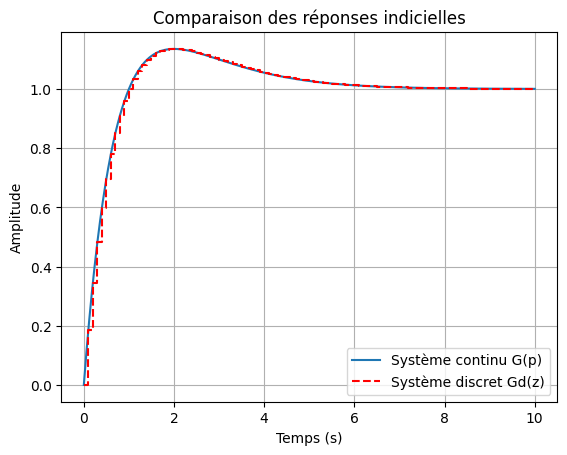

In [2]:
# 2. Réponses indicielles comparées
print("\n2. Visualisation et Comparaison des réponses indicielles:")

# Système continu
t_cont = np.linspace(0, 10, 1000)
y_cont, _ = step(G, t_cont)

# Système discret - temps doit être multiple de Te
n_points = int(10 / Te) + 1
t_disc = np.linspace(0, 10, n_points)
y_disc, _ = step(Gd, t_disc)

plt.figure("Exercice 1 - Réponses indicielles")
plt.plot(t_cont, y_cont, label='Système continu G(p)')
plt.step(t_disc, y_disc, 'r--', where='post', label='Système discret Gd(z)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Comparaison des réponses indicielles')
plt.legend()
plt.grid(True)
plt.show()


In [4]:
print("\n=== Exercice 2 ===")


=== Exercice 2 ===



Soit la fonction de transfert échantillonnée suivante :
Hd(z) = $\frac{0.047z + 0.046}{z2 − 1.81z + 0.9}$

1. Utiliser la fonction tf pour définir Hd (Te = 0.1s).

In [5]:
# 1. Définition de Hd(z)
num2 = [0.047, 0.046]
den2 = [1, -1.81, 0.9]
Hd = tf(num2, den2, Te)

print("\n1. Fonction de transfert Hd(z):")
print(Hd)



1. Fonction de transfert Hd(z):
<TransferFunction>: sys[6]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

   0.047 z + 0.046
  ------------------
  z^2 - 1.81 z + 0.9


2. Utiliser la fonction tf2zpk pour déterminer le gain, les zéros et les pôles de Hd.

In [6]:
# 2. Zéros, pôles et gain
zeros, poles, _ = tf2zpk(num2, den2)
gain = dcgain(Hd)

print("\n2. Analyse:")
print("Zéros: {zeros}")
print("Pôles: {poles}")
print("Gain statique: {gain[0]:.4f}")


2. Analyse:
Zéros: {zeros}
Pôles: {poles}
Gain statique: {gain[0]:.4f}


3. Visualiser les pôles et les zéros de Hd en utilisant la fonction pzmap.
Il faut utiliser l’instruction pzmap comme suit :
pzmap(Hd, Plot=True) : Plot = True permet d’afficher la figure.

C:\Users\loica\AppData\Roaming\Python\Python312\site-packages\control\pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


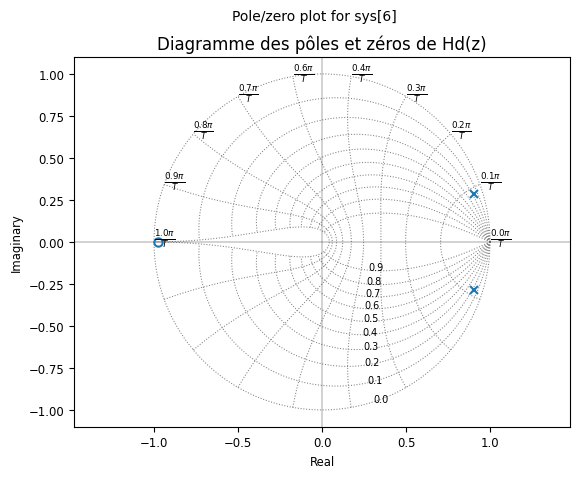

In [7]:
# 3. Diagramme pôles-zéros
plt.figure("Exercice 2 - Diagramme pôles-zéros")
pzmap(Hd, grid=True, plot=True)
plt.title('Diagramme des pôles et zéros de Hd(z)')
plt.show()


4. Retrouver les pôles de Hd avec la fonction pole

In [8]:
# 4. retrouvons et Vérification des pôles
print("\n4. Vérification des pôles:")
print(f"Avec pole(): {pole(Hd)}")


4. Vérification des pôles:
Avec pole(): [0.905+0.28456107j 0.905-0.28456107j]


In [10]:
print("\n=== Exercice 3 : Stabilité===")


=== Exercice 3 : Stabilité===



Soit la fonction de transfert échantillonnée suivante :
H(z) = $\frac{K}{z2 − 1.2z + 0.32}$
1. Quelle est la condition de stabilité d’un système échantillonné linéaire.

In [11]:
# 1. Condition de stabilité
print("\n1. Condition de stabilité:")
print("Un système échantillonné est stable si tous ses pôles sont à l'intérieur")
print("du cercle unité (module < 1) dans le plan complexe.")


1. Condition de stabilité:
Un système échantillonné est stable si tous ses pôles sont à l'intérieur
du cercle unité (module < 1) dans le plan complexe.


2. Déterminer les pôles de H(z) et conclure sur la stabilité de H.

In [12]:
# 2. Analyse de H(z)
num3 = [1]  # K=1 initialement
den3 = [1, -1.2, 0.32]
H = tf(num3, den3, Te)
poles_H = pole(H)

print("\n2. Analyse de stabilité de H(z):")
print(f"Pôles: {poles_H}")
print("Le système est stable car |pôles| < 1")


2. Analyse de stabilité de H(z):
Pôles: [0.8+0.j 0.4+0.j]
Le système est stable car |pôles| < 1


3. On intègre H dans une boucle fermée à retour unitaire. Pour K = 1, calculer la
nouvelle fonction de transfert Hb.

In [13]:
# 3-4. Boucle fermée nouvelle fonction de transfer 
print("\n3-4. Boucle fermée avec K=1:")
Hb = feedback(H, 1)
print("Fonction de transfert en boucle fermée Hb(z):")
print(Hb)


3-4. Boucle fermée avec K=1:
Fonction de transfert en boucle fermée Hb(z):
<TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

          1
  ------------------
  z^2 - 1.2 z + 1.32


4. Retrouver le résultat précédent en utilisant l’instruction feedback (Te = 0.1s)

In [15]:
# 6. Analyse pour K=0.67 et K=0.68
print("\n6. Analyse pour différents gains:")
for K in [0.67, 0.68]:
    Hb_temp = feedback(K*H, 1)
    poles = pole(Hb_temp)
    print(f"K={K:.2f} - Pôles: {poles} - Stable: {all(abs(poles) < 1)}")



6. Analyse pour différents gains:
K=0.67 - Pôles: [0.6+0.79372539j 0.6-0.79372539j] - Stable: True
K=0.68 - Pôles: [0.6+0.8j 0.6-0.8j] - Stable: False


5. Localiser les pôles de Hb pour K = 0.67 et K = 0.68 en utilisant rlocus.
Il faut utiliser l’instruction rlocus comme suit :
- rlist, klist = rlocus(Hb) : permet de trouver l’emplacement des pôles.
- plt.show() : pour tracer la figure.

C:\Users\loica\AppData\Roaming\Python\Python312\site-packages\control\rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


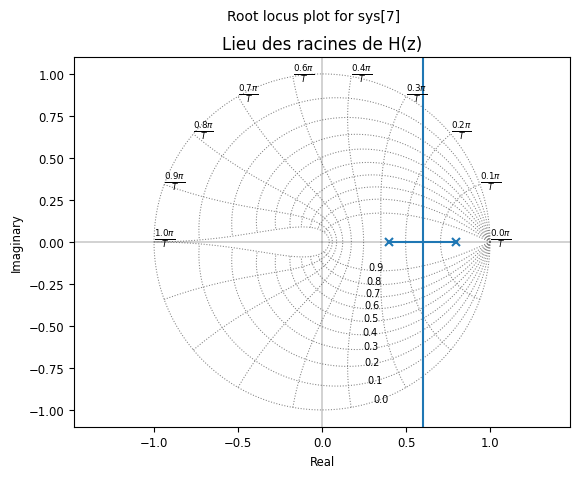

In [16]:
# 5. Lieu des racines
plt.figure("Exercice 3 - Lieu des racines")
rlocus(H)
plt.title('Lieu des racines de H(z)')
plt.show()

6. Donner la condition de stabilité.
Utiliser la fonction pole pour afficher les valeurs des pôles si nécessaire.


7. Observer les réponses indicielles pour K = 0.6 et K = 0.68

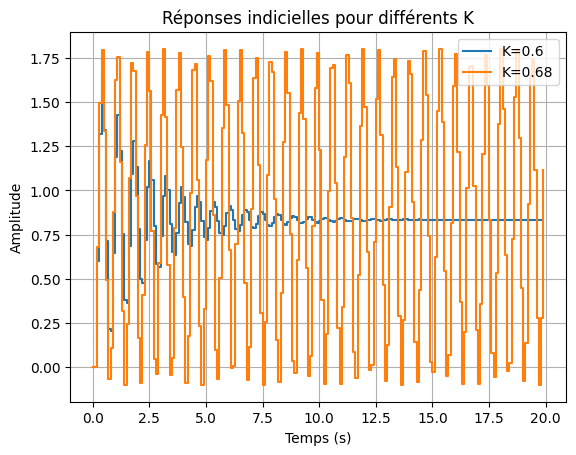

In [18]:
# 7. Réponses indicielles
plt.figure("Exercice 3 - Réponses indicielles")
for K in [0.6, 0.68]:
    Hb_temp = feedback(K*H, 1)
    t = np.arange(0, 20, Te)
    y, _ = step(Hb_temp, t)
    plt.step(t, y, where='post', label=f'K={K}')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Réponses indicielles pour différents K')
plt.legend()
plt.grid(True)
plt.show()




In [21]:
print("\n=== Exercice 4 :Erreur de position ===")


=== Exercice 4 :Erreur de position ===




Soit la fonction de transfert échantillonnée suivante :
Hd(z) =$\frac{0.9z}{z − 0.9}$

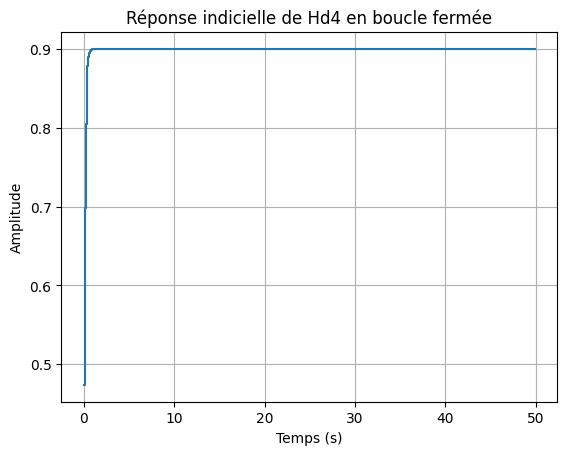

In [24]:


num4 = [0.9, 0]
den4 = [1, -0.9]
Hd4 = tf(num4, den4, Te)
Hd4_bf = feedback(Hd4, 1)

# Réponse indicielle
t = np.arange(0, 50, Te)
y, _ = step(Hd4_bf, t)
plt.figure("Exercice 4 - Réponse indicielle")
plt.step(t, y, where='post')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Réponse indicielle de Hd4 en boucle fermée')
plt.grid(True)
plt.show()


1. Déterminer graphiquement l’erreur de position du système en boucle fermée en considérant un retour unitaire.


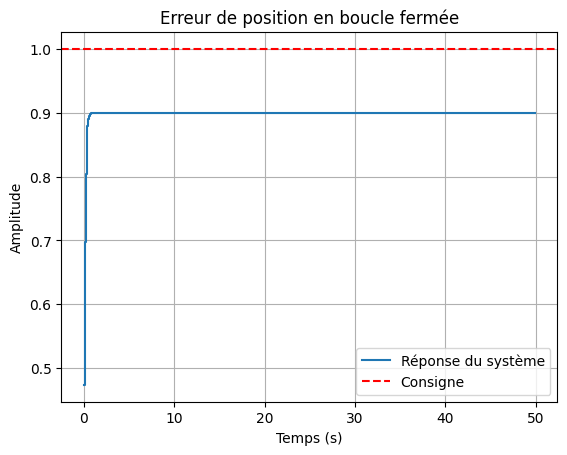

In [26]:
num4 = [0.9, 0]
den4 = [1, -0.9]
Hd4 = tf(num4, den4, Te)
Hd4_bf = feedback(Hd4, 1)

# Réponse indicielle
t = np.arange(0, 50, Te)
y, _ = step(Hd4_bf, t)

plt.figure("Exercice 4 - Erreur de position")
plt.step(t, y, where='post', label='Réponse du système')
plt.axhline(1, color='r', linestyle='--', label='Consigne')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Erreur de position en boucle fermée')
plt.legend()
plt.grid(True)
plt.show()



Calcul de l'erreur de position graphiquement 

In [27]:
# Calcul de l'erreur de position
error = 1 - y[-1]
print(f"\nErreur de position: {error:.4f}")


Erreur de position: 0.1000


In [28]:
print("\n=== Exercice 5 - Influence de la période d’échantillonnage sur la stabilité ===")


=== Exercice 5 - Influence de la période d’échantillonnage sur la stabilité ===



Soit la fonction de transfert continue suivante :
H(p) = $\frac{10}{0.1p + 1}$
1. Soit Hd1(z) et Hd2(z) les fonctions de transfert échantillonnées issues de H(p) respectivement pour les périodes d’échantillonnage Te1 = 0.1s et Te1 = 0.01s. Définir, sous
Python, Hd1(z) et Hd2(z).


In [30]:
# Système continu
num5 = [10]
den5 = [0.1, 1]
H = tf(num5, den5)
print("\n1. Système continu H(p):")
print(H)


1. Système continu H(p):
<TransferFunction>: sys[67]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     10
  ---------
  0.1 s + 1



Pôles en boucle fermée:
Pour Te=0.1s: [-5.95332615+0.j]
Pour Te=0.01s: [-0.0467884+0.j]


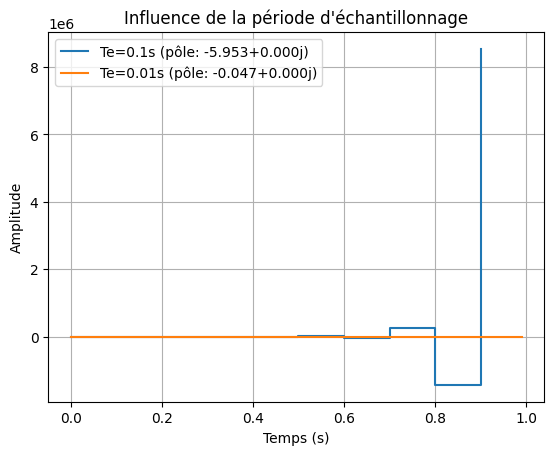


Conclusion:
À mesure que la période d'échantillonnage diminue par rapport à la constante de temps du système continu, la réponse discrète devient plus proche de la réponse continue


In [31]:
# Discrétisation avec deux périodes
Te1 = 0.1  # 10% de la constante de temps (tau=0.1s)
Te2 = 0.01  # 1% de la constante de temps

Ha1 = c2d(H, Te1, 'zoh')
Ha2 = c2d(H, Te2, 'zoh')

# Boucles fermées
Hbf1 = feedback(Ha1, 1)
Hbf2 = feedback(Ha2, 1)

print("\nPôles en boucle fermée:")
print(f"Pour Te=0.1s: {pole(Hbf1)}")
print(f"Pour Te=0.01s: {pole(Hbf2)}")

# Réponses indicielles
t1 = np.arange(0, 1, Te1)
t2 = np.arange(0, 1, Te2)
y1, _ = step(Hbf1, t1)
y2, _ = step(Hbf2, t2)

plt.figure("Exercice 5 - Influence de Te")
plt.step(t1, y1, where='post', label=f'Te=0.1s (pôle: {pole(Hbf1)[0]:.3f})')
plt.step(t2, y2, where='post', label=f'Te=0.01s (pôle: {pole(Hbf2)[0]:.3f})')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Influence de la période d\'échantillonnage')
plt.legend()
plt.grid(True)
plt.show()

print("\nConclusion:")
print("À mesure que la période d'échantillonnage diminue par rapport à la constante de temps du système continu, la réponse discrète devient plus proche de la réponse continue")
